# Week 3: Multi-Source Data Pipeline

This notebook builds a simple operations analytics pipeline by combining three distinct data sources:

- Internal operational records stored in a CSV file
- External weather data fetched from a public API
- Supplementary staffing and holiday context stored in a local SQLite database

The final master dataset is used to explore whether rainfall is associated with changes in operational throughput.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import requests
import sqlite3
import matplotlib.pyplot as plt

from sqlalchemy import create_engine

# Display plots directly in the notebook
%matplotlib inline

## Source 1: Internal CSV Dataset

The internal operational dataset contains daily records for production zones, shifts, throughput, efficiency, and downtime. These columns will be used as the core operational context for the pipeline.

In [2]:
# ==========================================
# Source 1: Load Internal Operational Dataset
# ==========================================

# Read the internal operational dataset from the provided CSV file.
# This file is our primary operational source and contains daily productivity metrics.
ops_df = pd.read_csv("mock_ops.csv")

# Convert the date column to datetime so later joins can align on calendar dates.
ops_df["Date"] = pd.to_datetime(ops_df["Date"])

# Sort by date for easier downstream analysis.
ops_df = ops_df.sort_values("Date").reset_index(drop=True)

# Keep the core operational columns and make the schema explicit for downstream work.
ops_df = ops_df[["Date", "Zone", "Shift", "Throughput", "Efficiency", "Downtime", "Machine_ID"]]

# Preview the internal dataset.
ops_df.head()

,Date,Zone,Shift,Throughput,Efficiency,Downtime,Machine_ID
0,2026-07-01,A,Morning,320,92,5,M001
1,2026-07-02,A,Evening,310,90,7,M002
2,2026-07-03,B,Morning,295,88,10,M003
3,2026-07-04,B,Evening,280,85,12,M004
4,2026-07-05,C,Morning,330,94,4,M005


## Source 2: External Weather API

The next source is an external weather feed. A public API is queried for daily rainfall data at a target location so the operational records can be enriched with environmental context.

In [3]:
# ==========================================
# Source 2: Fetch External Weather Data
# ==========================================

# Define the location and date range for the API call.
# The Open-Meteo archive endpoint provides daily weather observations for the selected location.
city = "London"
start_date = ops_df["Date"].min().strftime("%Y-%m-%d")
end_date = ops_df["Date"].max().strftime("%Y-%m-%d")

url = f"https://archive-api.open-meteo.com/v1/archive?latitude=51.5074&longitude=-0.1278&start_date={start_date}&end_date={end_date}&daily=precipitation_sum&timezone=UTC"

try:
    # Send the request and validate the response.
    response = requests.get(url, timeout=20)
    response.raise_for_status()
    weather_payload = response.json()

    # Build a weather dataframe with one row per day.
    weather_df = pd.DataFrame({
        "Date": pd.to_datetime(weather_payload["daily"]["time"]),
        "Rainfall_mm": weather_payload["daily"]["precipitation_sum"]
    })
    print("Weather API request succeeded.")
except Exception as e:
    # If the API fails, create a fallback dataframe so the notebook can still run.
    print(f"Weather API request failed: {e}")
    weather_df = pd.DataFrame({
        "Date": pd.date_range(start=start_date, end=end_date, freq="D"),
        "Rainfall_mm": np.nan
    })

# Preview the external weather dataset.
weather_df.head()

Weather API request succeeded.


,Date,Rainfall_mm
0,2026-07-01,0.0
1,2026-07-02,0.1
2,2026-07-03,0.0
3,2026-07-04,0.0
4,2026-07-05,0.0


## Source 3: SQLite Database

A small SQLite database is created locally to hold supplementary operational context such as holiday dates and staffing information. The data is queried with SQL and loaded into a DataFrame for integration.

In [5]:
# ==========================================
# Source 3: Create SQLite Database and Query Summary
# ==========================================

# Create a local SQLite database engine using SQLAlchemy.
engine = create_engine("sqlite:///operations_support.db")

# Create holiday and staffing tables with a few example rows.
# These columns add context that can help explain operational performance.
with engine.connect() as conn:
    conn.exec_driver_sql("""
        CREATE TABLE IF NOT EXISTS holiday_calendar (
            Date TEXT PRIMARY KEY,
            Is_Holiday INTEGER,
            Holiday_Name TEXT
        )
    """)
    conn.exec_driver_sql("""
        CREATE TABLE IF NOT EXISTS employee_shifts (
            Date TEXT PRIMARY KEY,
            Shift TEXT,
            Staff_Coverage INTEGER
        )
    """)

    conn.exec_driver_sql("""
        INSERT OR REPLACE INTO holiday_calendar (Date, Is_Holiday, Holiday_Name) VALUES
        ('2026-07-01', 0, 'None'),
        ('2026-07-02', 0, 'None'),
        ('2026-07-03', 0, 'None'),
        ('2026-07-04', 0, 'None'),
        ('2026-07-05', 0, 'None'),
        ('2026-07-06', 0, 'None'),
        ('2026-07-07', 1, 'Week 3 Holiday')
    """)

    conn.exec_driver_sql("""
        INSERT OR REPLACE INTO employee_shifts (Date, Shift, Staff_Coverage) VALUES
        ('2026-07-01', 'Morning', 12),
        ('2026-07-02', 'Evening', 10),
        ('2026-07-03', 'Morning', 11),
        ('2026-07-04', 'Evening', 9),
        ('2026-07-05', 'Morning', 13),
        ('2026-07-06', 'Evening', 10),
        ('2026-07-07', 'Morning', 8)
    """)

    conn.commit()

# Use a SQL query with JOIN and GROUP BY to summarize staffing and holiday context.
# The result is loaded directly into a DataFrame via pd.read_sql.
db_query = """
SELECT
    h.Date,
    h.Is_Holiday,
    h.Holiday_Name,
    s.Shift,
    AVG(s.Staff_Coverage) AS Avg_Staff_Coverage
FROM holiday_calendar h
LEFT JOIN employee_shifts s
    ON h.Date = s.Date
GROUP BY h.Date, h.Is_Holiday, h.Holiday_Name, s.Shift
ORDER BY h.Date
"""

support_df = pd.read_sql(db_query, engine)
support_df["Date"] = pd.to_datetime(support_df["Date"])
support_df = support_df.reset_index(drop=True)

# Preview the database-derived dataset.
support_df.head()

,Date,Is_Holiday,Holiday_Name,Shift,Avg_Staff_Coverage
0,2026-07-01,0,None,Morning,12.0
1,2026-07-02,0,None,Evening,10.0
2,2026-07-03,0,None,Morning,11.0
3,2026-07-04,0,None,Evening,9.0
4,2026-07-05,0,None,Morning,13.0


## Integration: Merge All Sources

The three datasets are merged into one master DataFrame on the shared date field. Missing values are handled so the resulting table remains usable for analysis.

In [6]:
# ==========================================
# Integration: Merge All Sources into a Master DataFrame
# ==========================================

# Merge the operational data with weather and support context.
# The date field is the common key across all sources.
master_df = ops_df.merge(weather_df, on="Date", how="left").merge(support_df, on="Date", how="left")

# Fill missing weather values with zero rainfall for days where no API data was returned.
# This avoids dropping important rows during the analysis.
master_df["Rainfall_mm"] = master_df["Rainfall_mm"].fillna(0)

# Fill missing support fields with neutral/default values where no database record exists.
master_df["Is_Holiday"] = master_df["Is_Holiday"].fillna(0)
master_df["Holiday_Name"] = master_df["Holiday_Name"].fillna("None")
master_df["Avg_Staff_Coverage"] = master_df["Avg_Staff_Coverage"].fillna(0)

# Ensure the final dataset is ordered by date.
master_df = master_df.sort_values("Date").reset_index(drop=True)

# Preview the combined master dataset.
master_df.head()

,Date,Zone,Shift_x,Throughput,Efficiency,Downtime,Machine_ID,Rainfall_mm,Is_Holiday,Holiday_Name,Shift_y,Avg_Staff_Coverage
0,2026-07-01,A,Morning,320,92,5,M001,0.0,0,None,Morning,12.0
1,2026-07-02,A,Evening,310,90,7,M002,0.1,0,None,Evening,10.0
2,2026-07-03,B,Morning,295,88,10,M003,0.0,0,None,Morning,11.0
3,2026-07-04,B,Evening,280,85,12,M004,0.0,0,None,Evening,9.0
4,2026-07-05,C,Morning,330,94,4,M005,0.0,0,None,Morning,13.0


## Analysis: Correlation

A correlation analysis is performed to assess whether higher rainfall is associated with lower throughput in the integrated dataset.

Correlation between rainfall and throughput: 0.075


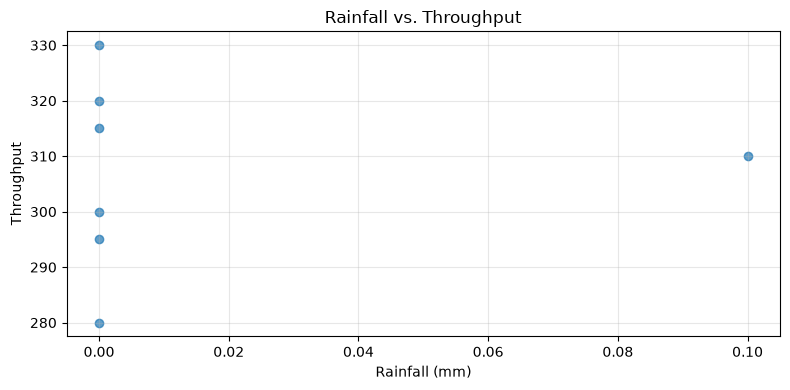

In [7]:
# ==========================================
# Analysis: Correlation Between Rainfall and Throughput
# ==========================================

# Correlation is calculated between the weather and operations columns.
# A negative value would suggest that rainier days coincide with lower throughput.
correlation = master_df[["Rainfall_mm", "Throughput"]].corr().loc["Rainfall_mm", "Throughput"]

print(f"Correlation between rainfall and throughput: {correlation:.3f}")

# Plot the relationship to visualize the trend.
plt.figure(figsize=(8, 4))
plt.scatter(master_df["Rainfall_mm"], master_df["Throughput"], alpha=0.7)
plt.title("Rainfall vs. Throughput")
plt.xlabel("Rainfall (mm)")
plt.ylabel("Throughput")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()